# Requirements

In [4]:
! pip install simpletransformers==0.63.11
! pip install transformers==4.30.2
! pip install emoji==2.4.0
! pip install contractions==0.1.73
! pip install twitter-text-parser==3.0.0

  Using cached transformers-4.30.2-py3-none-any.whl.metadata (113 kB)
  Using cached tokenizers-0.13.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.30.2-py3-none-any.whl (7.2 MB)
Using cached tokenizers-0.13.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (7.8 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]
      Successfully uninstalled transformers-4.57.6━━━━━━━━━━━━━━━━ 1/2 [transformers]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers] [transformers]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depende

In [1]:
import os
import json
import torch
import contractions
import pandas as pd
from tqdm import tqdm; tqdm.pandas()
from emoji import demojize
from nltk.tokenize import TweetTokenizer
from sklearn.model_selection import StratifiedKFold
from simpletransformers.classification import ClassificationModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from twitter_text import parse_tweet, extract_urls_with_indices, extract_emojis_with_indices
from collections import Counter
from spacy.lang.en import English
from transformers import AutoConfig

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
ARGUMENT = 'Argument'
NOARGUMENT = 'No-Argument'

NONE = "None"
NOTIFICATION = "Notification"
STATEMENT = "Statement"
REASON = "Reason"

class2id = {REASON: 0, STATEMENT: 1, NOTIFICATION: 2, NONE: 3}
id2class = {v: k for k, v in class2id.items()}
category2id = {NOARGUMENT: 0, ARGUMENT: 1}

UNDECIDED = 'Undecided'

CV_OUTPUT = '/home/baloni/Perspective-Aware-KG/data/processed/bertweet_cv_predictions.csv'

# Data Preparation

In [3]:
# Pre-processing for BERTweets as required from the authors, taken from: https://github.com/VinAIResearch/BERTweet/blob/master/TweetNormalizer.py
tokenizer = TweetTokenizer()

def normalizeToken(token):
    lowercased_token = token.lower()
    if token.startswith("@"):
        return "@USER"
    elif lowercased_token.startswith("http") or lowercased_token.startswith("www"):
        return "HTTPURL"
    elif len(token) == 1:
        return demojize(token)
    else:
        if token == "’":
            return "'"
        elif token == "…":
            return "..."
        else:
            return contractions.fix(token) # Change in code, the original version does not resolve all contractions

def normalizeTweet(tweet):
    tokens = tokenizer.tokenize(tweet.replace("’", "'").replace("…", "..."))
    normTweet = " ".join([normalizeToken(token) for token in tokens])

    normTweet = (
        normTweet.replace("cannot ", "can not ")
        .replace("n't ", " n't ")
        .replace("n 't ", " n't ")
        .replace("ca n't", "can't")
        .replace("ai n't", "ain't")
    )
    normTweet = (
        normTweet.replace("'m ", " 'm ")
        .replace("'re ", " 're ")
        .replace("'s ", " 's ")
        .replace("'ll ", " 'll ")
        .replace("'d ", " 'd ")
        .replace("'ve ", " 've ")
    )
    normTweet = (
        normTweet.replace(" p . m .", "  p.m.")
        .replace(" p . m ", " p.m ")
        .replace(" a . m .", " a.m.")
        .replace(" a . m ", " a.m ")
    )

    return " ".join(normTweet.split())

In [4]:
df_majority = pd.read_csv('/home/baloni/Perspective-Aware-KG/data/TACO/majority_votes.csv', index_col='tweet_id', keep_default_na=False, na_values=[''])
df_backup = pd.read_csv('/home/baloni/Perspective-Aware-KG/data/TACO/backup_tweets.csv', index_col='tweet_id', lineterminator='\n')

df_majority = df_majority[df_majority['class'] != UNDECIDED].copy()
df_majority['class'] = df_majority['class'].replace(class2id)
df_majority = df_majority.merge(right=df_backup, on='tweet_id')
df_majority['text'] = df_majority.progress_apply(lambda row: normalizeTweet(row.text), axis=1)

/tmp/ipykernel_3439887/2301550156.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_majority['class'] = df_majority['class'].replace(class2id)
100%|██████████| 1734/1734 [00:00<00:00, 2369.17it/s]


In [19]:
# Load perspective-enriched data
df_perspectives = pd.read_csv('/home/baloni/Perspective-Aware-KG/data/processed/perspective_enriched.csv')

# Filter out Undecided (matching TACO's approach)
df_perspectives = df_perspectives[df_perspectives['taco_class'] != 'undecided'].copy()

# Normalize text with BERTweet preprocessing
df_perspectives['text'] = df_perspectives.progress_apply(
    lambda row: normalizeTweet(row['text']), 
    axis=1
)

# Class encoding (matching TACO)
class2id = {"reason": 0, "statement": 1, "notification": 2, "none": 3}
df_perspectives['taco_class'] = df_perspectives['taco_class'].replace(class2id)

# Separate features
'''
perspective_cols = [
    'information_providing', 'information_seeking', 'epistemic',
    'experiential', 'opinion', 'aot',
    'max_conf_information_providing', 'max_conf_information_seeking', 'max_conf_epistemic',
    'max_conf_experiential', 'max_conf_opinion', 'max_conf_aot',
    'num_perspectives', 'avg_confidence'
]
'''

from itertools import combinations

# Original perspective features
perspective_cols = [
    'information_providing', 'information_seeking', 'epistemic',
    'experiential', 'opinion', 'aot'
]

X_perspective = df_perspectives[perspective_cols].values
y = df_perspectives['taco_class'].values

100%|██████████| 1734/1734 [00:00<00:00, 5271.15it/s]
/tmp/ipykernel_3439887/3070481443.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_perspectives['taco_class'] = df_perspectives['taco_class'].replace(class2id)


In [6]:
# Merged TACO csv data loading to include conversations for tweets
taco_df = pd.read_csv("/home/baloni/Perspective-Aware-KG/data/processed/merged_taco_data.csv", dtype={"tweet_id": str, "parent_id": str})

# Map tweet_id → text
id2text = dict(zip(taco_df["tweet_id"], taco_df["text"]))

# Ensure tweet_id is string in df_perspectives
df_perspectives["tweet_id"] = df_perspectives["tweet_id"].astype(str)

# Add parent_id from TACO
df_perspectives = df_perspectives.merge(
    taco_df[["tweet_id", "parent_id"]],
    on="tweet_id",
    how="left"
)

# Build parent_text column
def get_parent_text(row):
    pid = row["parent_id"]
    tid = row["tweet_id"]
    if pid.lower() == "nan" or pid == tid:
        return ""  # root tweet → no parent
    return id2text.get(pid, "")
df_perspectives["parent_text"] = df_perspectives.apply(get_parent_text, axis=1)

df_perspectives["parent_text"] = df_perspectives["parent_text"].fillna("").astype(str)


# Cross-Validation

In [20]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from torch.utils.data import Dataset
import torch

class TweetPerspectiveDataset(Dataset):
    """
    Custom dataset that combines BERTweet text features 
    with perspective features
    """
    '''
    def __init__(self, texts, labels, perspectives, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.perspectives = torch.FloatTensor(perspectives)
        self.tokenizer = tokenizer
        self.max_length = max_length
    '''
    """
    Text + Parent tweet + Perspectives
    """
    def __init__(self, texts, labels, perspectives, tokenizer, max_length=128, num_persp_features=None): 
        self.texts = texts 
        #self.parent_texts = parent_texts 
        self.labels = labels 
        self.perspectives = torch.FloatTensor(perspectives) 
        self.tokenizer = tokenizer 
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        '''
        parent_encoding = self.tokenizer( 
            self.parent_texts[idx], 
            truncation=True, 
            padding="max_length", 
            max_length=self.max_length, 
            return_tensors="pt" )
        '''
        '''
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        item["perspectives"] = self.perspectives[idx]
        '''
        item = { 
            "input_ids": encoding["input_ids"].squeeze(0), 
            "attention_mask": encoding["attention_mask"].squeeze(0), 
            #"parent_input_ids": parent_encoding["input_ids"].squeeze(0), 
            #"parent_attention_mask": parent_encoding["attention_mask"].squeeze(0), 
            "labels": torch.tensor(self.labels[idx], dtype=torch.long), 
            "perspectives": self.perspectives[idx] 
            }
        return item

In [21]:
class BERTweetWithPerspectives(torch.nn.Module):
    """
    BERTweet encoder + perspective features (direct concatenation, no MLP)
    """
    def __init__(self, num_labels=4, num_perspective_features=len(perspective_cols)):
        super().__init__()
        self.bertweet = AutoModelForSequenceClassification.from_pretrained(
            "vinai/bertweet-base",
            num_labels=num_labels
        )
        
        # Get BERTweet's hidden size (768 for base)
        hidden_size = self.bertweet.config.hidden_size
        
        # Fusion layer: directly concatenate BERTweet + perspectives
        self.fusion = torch.nn.Linear(hidden_size + num_perspective_features, hidden_size)
        
        # Final classifier
        self.classifier = torch.nn.Linear(hidden_size, num_labels)
        
    def forward(self, input_ids, attention_mask, perspectives, labels=None):
        # Get BERTweet embeddings
        outputs = self.bertweet.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Take [CLS] token embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        # Direct concatenation (no MLP)
        combined = torch.cat([cls_embedding, perspectives], dim=1)
        fused = torch.relu(self.fusion(combined))
        
        # Classification
        logits = self.classifier(fused)
        
        loss = None
        if labels is not None:
            loss_fct = torch.nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)
        
        return {
            'loss': loss,
            'logits': logits
        }

In [7]:
import torch
import torch.nn as nn

class PerspectiveGuidedBERTweet(nn.Module):
    """
    Perspectives guide attention over BERTweet representations
    """
    def __init__(self, num_labels=4, num_perspective_features=6):
        super().__init__()
        self.bertweet = AutoModelForSequenceClassification.from_pretrained(
            "vinai/bertweet-base",
            num_labels=num_labels
        )
        
        hidden_size = self.bertweet.config.hidden_size  # 768
        
        # Perspective encoder (learns importance)
        self.perspective_encoder = nn.Sequential(
            nn.Linear(num_perspective_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, hidden_size)  # Same dim as BERTweet
        )
        
        # Multi-head attention: perspectives attend to text
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # Layer norm for stability
        self.layer_norm = nn.LayerNorm(hidden_size)
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),  # [text; attended]
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, num_labels)
        )
        
    def forward(self, input_ids, attention_mask, perspectives, labels=None):
        # Get BERTweet embeddings
        outputs = self.bertweet.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        text_hidden = outputs.last_hidden_state  # (batch, seq_len, 768)
        cls_token = text_hidden[:, 0, :]  # (batch, 768)
        
        # Encode perspectives
        persp_encoded = self.perspective_encoder(perspectives)  # (batch, 768)
        persp_query = persp_encoded.unsqueeze(1)  # (batch, 1, 768)
        
        # Perspectives attend to text (find relevant parts)
        attended, attn_weights = self.cross_attention(
            query=persp_query,      # What perspectives want
            key=text_hidden,        # Text keys
            value=text_hidden       # Text values
        )
        attended = attended.squeeze(1)  # (batch, 768)
        
        # Residual connection + layer norm
        attended = self.layer_norm(attended + persp_encoded)
        
        # Combine CLS token + perspective-attended representation
        combined = torch.cat([cls_token, attended], dim=1)  # (batch, 1536)
        
        # Classify
        logits = self.classifier(combined)
        
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)
        
        return {
            'loss': loss,
            'logits': logits,
            'attention_weights': attn_weights  # For analysis
        }

In [22]:
class PerspectiveCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch):
        input_ids = torch.stack([item["input_ids"] for item in batch])
        attention_mask = torch.stack([item["attention_mask"] for item in batch])
        #parent_input_ids = torch.stack([item["parent_input_ids"] for item in batch]) 
        #parent_attention_mask = torch.stack([item["parent_attention_mask"] for item in batch])
        perspectives = torch.stack([item["perspectives"] for item in batch])
        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            #"parent_input_ids": parent_input_ids, 
            #"parent_attention_mask": parent_attention_mask,
            "perspectives": perspectives,
            "labels": labels
        }


In [10]:
import torch
import torch.nn as nn
from transformers import AutoModel

class BiEncoderCrossAttnWithPersp(nn.Module):
    def __init__(self, num_labels=4, num_perspective_features=len(perspective_cols), hidden_size=768):
        super().__init__()

        # Tweet encoder
        self.tweet_encoder = AutoModel.from_pretrained("vinai/bertweet-base")

        # Parent encoder (separate encoder, not shared)
        self.parent_encoder = AutoModel.from_pretrained("vinai/bertweet-base")

        # Cross-attention: tweet (query) attends to parent (key/value)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=8,
            batch_first=True
        )

        self.cross_ln = nn.LayerNorm(hidden_size)

        # Perspective MLP
        self.persp_mlp = nn.Sequential(
            nn.Linear(num_perspective_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # Fusion: [CLS_tweet, CLS_parent, CLS_cross, persp_emb]
        fusion_in = hidden_size * 3 + 16
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, hidden_size),
            nn.ReLU()
        )

        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(
        self,
        input_ids,
        attention_mask,
        parent_input_ids,
        parent_attention_mask,
        perspectives,
        labels=None
    ):
        # Encode tweet
        tweet_out = self.tweet_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        tweet_hidden = tweet_out.last_hidden_state          
        cls_tweet = tweet_hidden[:, 0, :]                   

        # Encode parent
        parent_out = self.parent_encoder(
            input_ids=parent_input_ids,
            attention_mask=parent_attention_mask
        )
        parent_hidden = parent_out.last_hidden_state        
        cls_parent = parent_hidden[:, 0, :]                 

        # Cross-attention: tweet CLS queries parent sequence
        # query: (B, 1, H), key/value: (B, T_p, H)
        query = cls_tweet.unsqueeze(1)
        key = parent_hidden
        value = parent_hidden

        cross_out, _ = self.cross_attn(query=query, key=key, value=value)
        cross_out = cross_out.squeeze(1)                    
        cross_out = self.cross_ln(cross_out + cls_tweet)    

        # Perspective embedding
        persp_emb = self.persp_mlp(perspectives)            

        # Fuse everything
        fused = torch.cat([cls_tweet, cls_parent, cross_out, persp_emb], dim=1)
        fused = self.fusion(fused)
        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits}


In [35]:
# ----- Using alternative code for study 5 -----

def engineer_perspective_interactions(df):
    """
    Create interaction features that capture perspective co-occurrence patterns
    """
    df = df.copy()
    
    # --- Pairwise AND interactions ---
    df['info_AND_opinion'] = (df['information_providing'] & df['opinion']).astype(int)
    df['epist_AND_info_prov'] = (df['epistemic'] & df['information_providing']).astype(int)
    df['opinion_AND_experiential'] = (df['opinion'] & df['experiential']).astype(int)
    df['info_AND_experiential'] = (df['information_providing'] & df['experiential']).astype(int)
    df['info_seek_AND_opinion'] = (df['information_seeking'] & df['opinion']).astype(int)
    
    # --- Task-specific signals ---
    # Statement = opinion + evidence
    df['statement_signal'] = (
        (df['opinion'] == 1) & 
        ((df['information_seeking'] == 1) & (df['experiential'] == 0))
    ).astype(int)
    
    # Reason = information + evidence, NOT opinion
    df['reason_signal'] = (
        (df['information_providing'] == 1) & 
        (df['experiential'] == 1) & 
        (df['opinion'] == 1)
    ).astype(int)
    
    # Notification = info providing only
    df['notification_signal'] = (
        (df['information_providing'] == 1) & 
        (df['epistemic'] == 0) & 
        (df['opinion'] == 0)
    ).astype(int)
    
    # None = no perspectives
    df['none_signal'] = (df[['epistemic', 'experiential','aot']].sum(axis=1) <= 2).astype(int)
    
    return df

# Apply
df_perspectives = engineer_perspective_interactions(df_perspectives)

# Update feature columns
interaction_cols = [
    'info_AND_opinion', 'epist_AND_info_prov', 'opinion_AND_experiential',
    'info_AND_experiential', 'info_seek_AND_opinion',
    'statement_signal', 'reason_signal', 'notification_signal', 'none_signal'
]

all_perspective_cols = perspective_cols + interaction_cols  # Use this in your model

In [24]:
from sklearn.model_selection import StratifiedKFold

collator = PerspectiveCollator(tokenizer)

skf = StratifiedKFold(n_splits=10, random_state=123456789, shuffle=True)
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=False)

df_predictions = pd.DataFrame()

for fold, (train_idx, test_idx) in enumerate(skf.split(df_perspectives, df_perspectives['taco_class'])):
    print(f"Fold {fold+1}/10")
    
    df_train = df_perspectives.iloc[train_idx]
    df_test = df_perspectives.iloc[test_idx]
    
    # Extract perspective features
    X_train_persp = df_train[perspective_cols].values
    X_test_persp = df_test[perspective_cols].values
    
    # Create datasets
    train_dataset = TweetPerspectiveDataset(
        df_train["text"].tolist(),
        #df_train["parent_text"].tolist(),
        df_train["taco_class"].tolist(),
        X_train_persp,
        tokenizer
    )
    
    test_dataset = TweetPerspectiveDataset(
        df_test["text"].tolist(),
        #df_test["parent_text"].tolist(),
        df_test["taco_class"].tolist(),
        X_test_persp,
        tokenizer
    )

    # Initialize model
    model = BERTweetWithPerspectives(
        num_labels=4,
        num_perspective_features=len(perspective_cols)
    )
    '''
    # Use the improved training args
    training_args = TrainingArguments(
        output_dir=f"./cv_fold_{fold}_improved",
        num_train_epochs=8,
        learning_rate=3e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        per_device_train_batch_size=16,
        gradient_accumulation_steps=2,
        evaluation_strategy="no",
        save_strategy="no",
        fp16=True,
        logging_steps=25
    )
    '''
    # Training
    training_args = TrainingArguments(
        output_dir=f"/home/baloni/Perspective-Aware-KG/data/training/cv_fold_{fold}_perspectives_context",
        num_train_epochs=5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=4e-5,
        save_strategy="no",
        logging_steps=50,
        report_to="none"
    )

    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=collator
    )
    
    trainer.train()
    
    # Predict
    preds = trainer.predict(test_dataset).predictions
    #additional check
    if isinstance(preds, tuple):
        preds = preds[0]
    preds = preds.argmax(axis=1)
    
    df_test_copy = df_test.copy()
    df_test_copy["class_pred"] = preds
    df_test_copy["tweet_id"] = df_test_copy.index
    df_predictions = pd.concat([df_predictions, df_test_copy[["tweet_id", "taco_class", "class_pred"]]])

# Save results
df_predictions.to_csv('/home/baloni/Perspective-Aware-KG/data/output/perspectives_cv_predictions.csv', index=False)

/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Fold 1/10


Some weights of the model checkpoint at vinai/bertweet-base were not used when initializing RobertaForSequenceClassification: ['lm_head.layer_norm.bias', 'lm_head.decoder.bias', 'lm_head.decoder.weight', 'roberta.pooler.dense.bias', 'lm_head.bias', 'roberta.pooler.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: 

Step,Training Loss
50,1.195800
100,1.032600
150,0.952200
200,0.832400
250,0.695100
300,0.641800
350,0.627700
400,0.520900
450,0.410800
500,0.477200


Fold 2/10


...

/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at vinai/bertweet-base were not used when initializing RobertaForSequenceClassification: ['lm_head.layer_norm.bias', 'lm_head.decoder.bias', 'lm_head.decoder.weight', 'roberta.pooler.dense.bias', 'lm_head.bias', 'roberta.pooler.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification f

Step,Training Loss
50,1.240100
100,1.098800
150,0.981200
200,0.913600
250,0.750700
300,0.765000
350,0.800300
400,0.635200
450,0.633800
500,0.539500


Fold 10/10


/home/baloni/Perspective-Aware-KG/CogPer/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at vinai/bertweet-base were not used when initializing RobertaForSequenceClassification: ['lm_head.layer_norm.bias', 'lm_head.decoder.bias', 'lm_head.decoder.weight', 'roberta.pooler.dense.bias', 'lm_head.bias', 'roberta.pooler.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification f

Step,Training Loss
50,1.237700
100,1.070100
150,0.979800
200,0.908100
250,0.832700
300,0.777200
350,0.668500
400,0.673900
450,0.557100
500,0.544700


# Evaluation

In [25]:
df_validation = pd.read_csv('/home/baloni/Perspective-Aware-KG/data/output/perspectives_cv_predictions.csv')
df_validation = df_validation.set_index('tweet_id')

# Ensure alignment with the dataset used in CV
assert sorted(df_perspectives.index) == sorted(df_validation.index)

for tweet_id in df_perspectives.index:
    assert df_perspectives.loc[tweet_id]['taco_class'] == df_validation.loc[tweet_id]['taco_class']

# Extract true and predicted labels
y_true = df_validation['taco_class'].tolist()
y_pred = df_validation['class_pred'].tolist()

# Binary mapping
label2id = {
    "reason": 0,
    "statement": 1,
    "notification": 2,
    "none": 3
}

positive_classes = [label2id["reason"], label2id["statement"]]

y_true_bin = [y in positive_classes for y in y_true]
y_pred_bin = [y in positive_classes for y in y_pred]


In [26]:
# binary classification evaluation
print(classification_report(y_true_bin, y_pred_bin, target_names=category2id.keys(), digits=4))

              precision    recall  f1-score   support

 No-Argument     0.8776    0.8331    0.8548       869
    Argument     0.8405    0.8832    0.8613       865

    accuracy                         0.8581      1734
   macro avg     0.8590    0.8582    0.8581      1734
weighted avg     0.8591    0.8581    0.8580      1734



In [27]:
# multi-class classification evaluation
print(classification_report(y_true, y_pred, target_names=class2id.keys(), digits=4))

              precision    recall  f1-score   support

      reason     0.7576    0.7745    0.7660       581
   statement     0.5429    0.6021    0.5710       284
notification     0.7731    0.7700    0.7715       500
        none     0.8410    0.7453    0.7902       369

    accuracy                         0.7388      1734
   macro avg     0.7286    0.7230    0.7247      1734
weighted avg     0.7446    0.7388    0.7408      1734



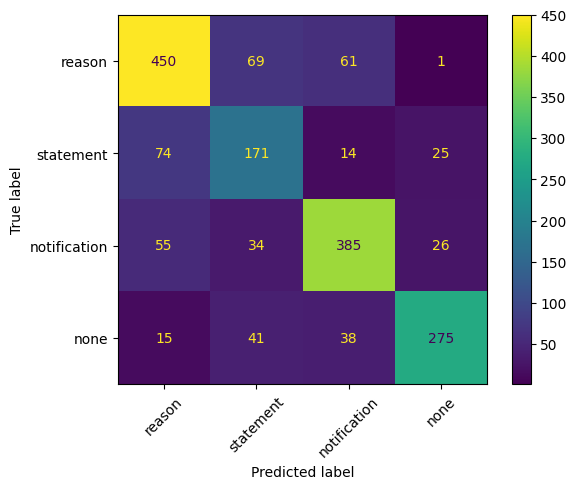

In [28]:
# y_true is a 1D array of true class labels, and y_pred is a 1D array of predicted class labels
cm = confusion_matrix(y_true, y_pred)

# display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class2id.keys())
disp.plot(xticks_rotation=45)

# Retraining